# Telco churn: exploratory analysis

Quick look at the data before building anything. The goal is to answer four questions:
what is in the table, what is broken, how imbalanced is the target, and which columns
seem to matter. Nothing is fitted in this notebook: it only motivated the fixed cleaning rules that
live in `churn/preprocessing.py` and run inside the sklearn Pipeline.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
from churn.config import DATA_PATH

pd.set_option("display.max_columns", 30)
plt.rcParams.update({"figure.dpi": 100, "axes.spines.top": False, "axes.spines.right": False})

df = pd.read_csv(DATA_PATH)
print(df.shape)
df.head(3)

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


## 1. Structure and data types

In [2]:
df.dtypes.to_frame("dtype").join(df.nunique().rename("unique values"))

,dtype,unique values
customerID,object,7043
gender,object,2
SeniorCitizen,int64,2
Partner,object,2
Dependents,object,2
tenure,int64,73
PhoneService,object,2
MultipleLines,object,3
InternetService,object,3
OnlineSecurity,object,3


21 columns, 7,043 customers, one row each. `customerID` is unique so it is an identifier
and gets dropped. `SeniorCitizen` is already 0/1, everything else is either a number
(`tenure`, `MonthlyCharges`) or text.

The one that stands out: **`TotalCharges` is text** although it is clearly a money amount.
That usually means a value that can't be parsed is hiding in there.

## 2. Missing values and the `TotalCharges` problem

In [3]:
print("total NaN cells:", int(df.isna().sum().sum()))

total = pd.to_numeric(df["TotalCharges"], errors="coerce")
blank = df[total.isna()]
print("values that fail to parse:", len(blank), "-> raw value:", set(blank["TotalCharges"].map(repr)))
blank[["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Contract", "Churn"]]

total NaN cells: 0
values that fail to parse: 11 -> raw value: {"' '"}


,customerID,tenure,MonthlyCharges,TotalCharges,Contract,Churn
488,4472-LVYGI,0,52.55,,Two year,No
753,3115-CZMZD,0,20.25,,Two year,No
936,5709-LVOEQ,0,80.85,,Two year,No
1082,4367-NUYAO,0,25.75,,Two year,No
1340,1371-DWPAZ,0,56.05,,Two year,No
3331,7644-OMVMY,0,19.85,,Two year,No
3826,3213-VVOLG,0,25.35,,Two year,No
4380,2520-SGTTA,0,20.00,,Two year,No
5218,2923-ARZLG,0,19.70,,One year,No
6670,4075-WKNIU,0,73.35,,Two year,No


No NaNs in the file, but 11 `TotalCharges` cells are a single space, which is why pandas
kept the column as text. All 11 rows have `tenure == 0`: customers who signed up but have
not been billed yet. None of them churned.

So "missing" here really means "zero so far". Filling with the column median (~1,400)
would invent a customer who has paid 1,400 after zero months. The fill I use is
`tenure * MonthlyCharges`, which is 0 for these rows, and is also a sensible estimate if a
blank ever shows up for someone with tenure > 0. Checking that this approximation is
reasonable on the rows where we do have a total:

In [4]:
ok = total.notna()
approx = (df["tenure"] * df["MonthlyCharges"])[ok]
print("correlation of tenure*MonthlyCharges with TotalCharges:", round(np.corrcoef(approx, total[ok])[0, 1], 4))
print("median absolute gap:", round((approx - total[ok]).abs().median(), 1), "dollars")

correlation of tenure*MonthlyCharges with TotalCharges: 0.9996
median absolute gap: 28.6 dollars


Correlation of 0.9996 and a small typical gap (about 2% of a typical total; presumably price or plan changes),
so the rule is fine. It is row-wise and learns nothing from the data, so it cannot leak
information between train and test.

Other checks:

In [5]:
print("duplicate customerIDs:", df["customerID"].duplicated().sum())
print("duplicate rows ignoring the ID:", df.drop(columns="customerID").duplicated().sum())
print()
for col in ["MultipleLines", "OnlineSecurity", "InternetService", "PhoneService"]:
    print(col, df[col].value_counts().to_dict())

duplicate customerIDs: 0
duplicate rows ignoring the ID: 22

MultipleLines {'No': 3390, 'Yes': 2971, 'No phone service': 682}
OnlineSecurity {'No': 3498, 'Yes': 2019, 'No internet service': 1526}
InternetService {'Fiber optic': 3096, 'DSL': 2421, 'No': 1526}
PhoneService {'Yes': 6361, 'No': 682}


- 22 rows repeat an earlier row once the ID is dropped (42 rows in 20 groups). All of them are
  tenure-1 customers, where `TotalCharges` equals `MonthlyCharges`, so there are very few distinct
  combinations to begin with. They look like coincidences between different customers, so I keep them.
- "No phone service" (682 rows) only repeats `PhoneService == "No"`, and "No internet service"
  (1,526 rows) repeats `InternetService == "No"`. I fold both into "No" so those columns
  are plain Yes/No. No information is lost since the parent column still says it.

## 3. Target balance

{'No': 5174, 'Yes': 1869} -> 26.5% churn
accuracy of always predicting 'No': 73.5%


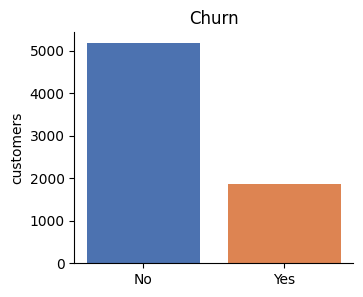

In [6]:
y = (df["Churn"] == "Yes").astype(int)
counts = df["Churn"].value_counts()
print(counts.to_dict(), "->", f"{y.mean():.1%} churn")
print(f"accuracy of always predicting 'No': {1 - y.mean():.1%}")

fig, ax = plt.subplots(figsize=(3.6, 3))
ax.bar(counts.index, counts.values, color=["#4c72b0", "#dd8452"])
ax.set(title="Churn", ylabel="customers")
plt.show()

About 27% churn, roughly 2.8 stayers for every leaver. Not extreme, but enough that a model
that never predicts churn is "73.5% accurate" and completely useless. That is the main
reason accuracy is not the metric here (see the README). I will use ROC-AUC and PR-AUC to
compare models, stratify every split, and choose the decision threshold explicitly instead
of assuming 0.5.

## 4. Numeric features vs churn

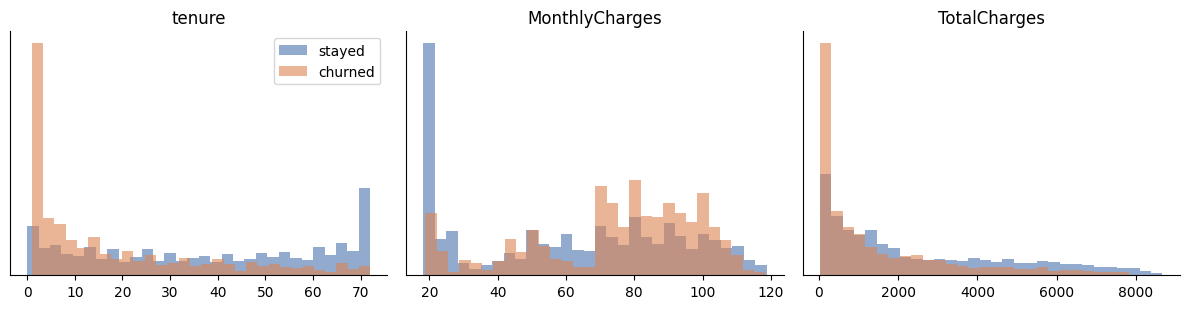

,tenure,MonthlyCharges,TotalCharges
churn,,,
0,38.0,64.4,1683.6
1,10.0,79.6,703.6


In [7]:
num = df.assign(TotalCharges=total, churn=y)
fig, axes = plt.subplots(1, 3, figsize=(12, 3.2))
for ax, col in zip(axes, ["tenure", "MonthlyCharges", "TotalCharges"]):
    for label, colour in [(0, "#4c72b0"), (1, "#dd8452")]:
        ax.hist(num.loc[num["churn"] == label, col].dropna(), bins=30, alpha=0.6,
                density=True, color=colour, label="churned" if label else "stayed")
    ax.set(title=col, yticks=[])
axes[0].legend()
plt.tight_layout()
plt.show()

num.groupby("churn")[["tenure", "MonthlyCharges", "TotalCharges"]].median().round(1)

- **Tenure** is the clearest signal: churners have a median tenure of 10 months vs 38 for
  stayers, and the histogram for churners piles up at the start of the relationship.
- **MonthlyCharges**: churners pay more (median ~80 vs ~64).
- **TotalCharges** is mostly tenure in disguise (correlation 0.83 with tenure), so it
  looks predictive but largely repeats what tenure already says.

,churn rate,customers
tenure,,
0-6,0.529,1481
7-12,0.359,705
13-24,0.287,1024
25-48,0.204,1594
49-72,0.095,2239


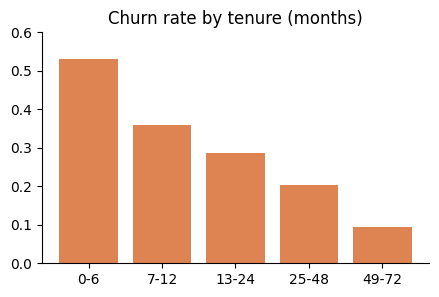

In [8]:
bands = pd.cut(df["tenure"], [-1, 6, 12, 24, 48, 72], labels=["0-6", "7-12", "13-24", "25-48", "49-72"])
rate = y.groupby(bands, observed=True).agg(["mean", "size"])
rate.columns = ["churn rate", "customers"]
display(rate.round(3))

fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(rate.index.astype(str), rate["churn rate"], color="#dd8452")
ax.set(title="Churn rate by tenure (months)", ylim=(0, 0.6))
plt.show()

Churn falls steadily with tenure: 53% in the first six months, under 10% after four years.

## 5. Categorical features vs churn

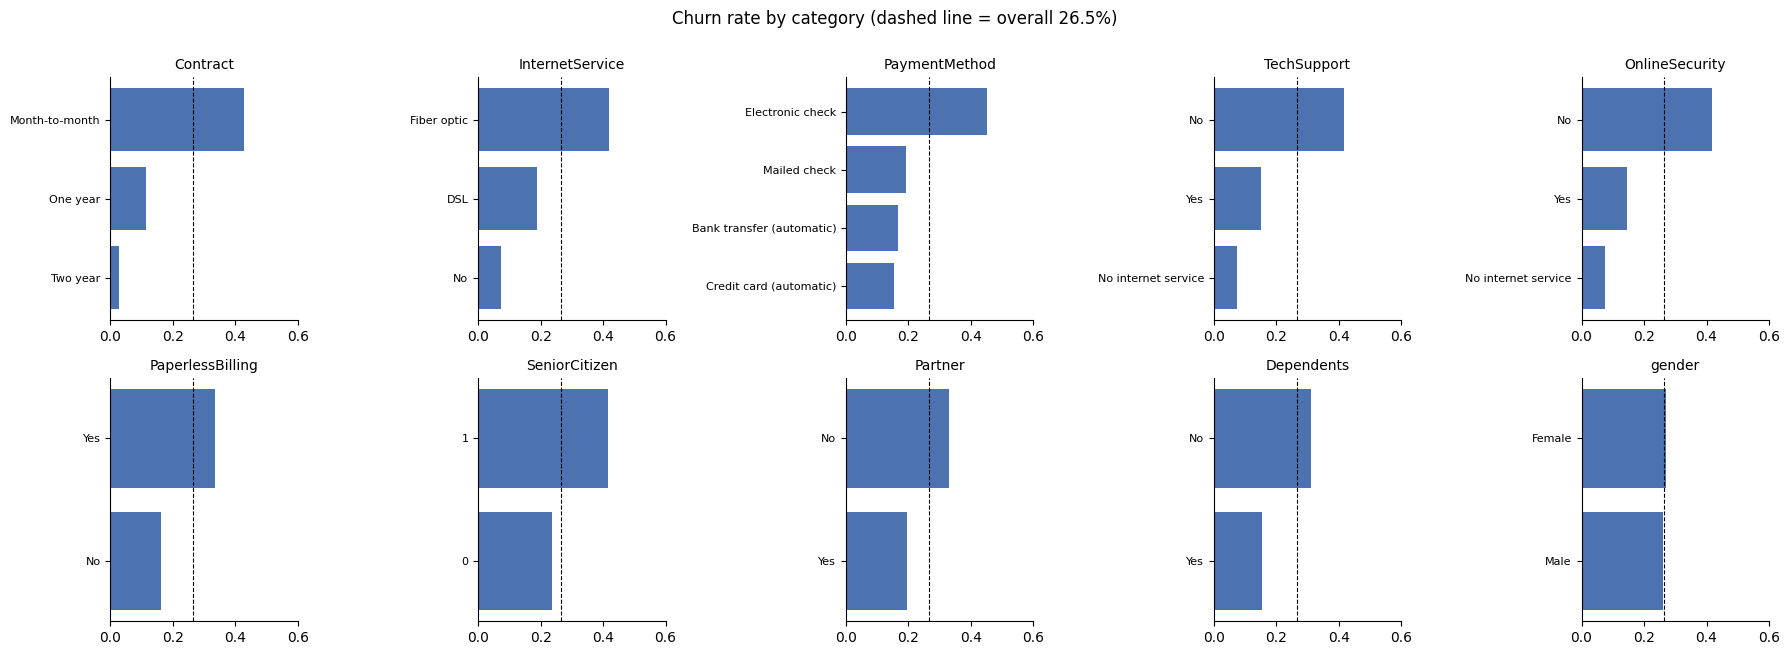

In [9]:
cols = ["Contract", "InternetService", "PaymentMethod", "TechSupport",
        "OnlineSecurity", "PaperlessBilling", "SeniorCitizen", "Partner", "Dependents", "gender"]
fig, axes = plt.subplots(2, 5, figsize=(18, 6.5))
for ax, col in zip(axes.ravel(), cols):
    rates = y.groupby(df[col]).mean().sort_values()
    ax.barh([str(i) for i in rates.index], rates.values, color="#4c72b0")
    ax.axvline(y.mean(), color="k", ls="--", lw=0.8)
    ax.set_title(col, fontsize=10)
    ax.tick_params(axis="y", labelsize=8)
    ax.set_xlim(0, 0.6)
for ax in axes.ravel():
    ax.set_ylabel("")
fig.suptitle("Churn rate by category (dashed line = overall 26.5%)", y=1.0)
plt.tight_layout()
plt.show()

What stands out:

- **Contract**: month-to-month 43% vs one year 11% vs two year 3%. The strongest single feature.
- **Internet service**: fibre customers churn at 42%, DSL 19%, no internet 7%. Fibre is also
  the most expensive plan (avg ~$92/month vs ~$58 for DSL), so price and plan are tangled together.
- **Payment method**: electronic check is 45%, the other three sit around 15-19%.
- **Support add-ons**: customers without tech support or online security churn ~42% vs ~15% with them.
- **Paperless billing, senior citizens, no partner, no dependents** all sit above average.
- **Gender** and **PhoneService** make almost no difference (26.9% vs 26.2%, and 24.9% vs 26.7%).

In [10]:
pivot = y.groupby([df["Contract"], df["InternetService"]]).agg(["mean", "size"])
pivot.columns = ["churn rate", "customers"]
pivot.round(3)

churn rate  customers
Contract       InternetService                       
Month-to-month DSL                   0.322       1223
               Fiber optic           0.546       2128
               No                    0.189        524
One year       DSL                   0.093        570
               Fiber optic           0.193        539
               No                    0.025        364
Two year       DSL                   0.019        628
               Fiber optic           0.072        429
               No                    0.008        638

Combining contract and plan shows why tree models could help a little: month-to-month
fibre customers are the high-risk segment (55% churn, 2,128 people), while two-year
customers barely leave whatever plan they are on. Those are interactions a plain logistic
regression only captures if we add them by hand.

## 6. What this means for the model

| Finding | What I do about it |
|---|---|
| `TotalCharges` is text, 11 blanks (all tenure 0) | parse to float, fill with `tenure * MonthlyCharges` (= 0 for those rows) |
| "No internet / phone service" repeats another column | fold into "No" |
| Everything else is categorical text | one-hot encode (binary columns become a single 0/1 column) |
| ~27% churn | stratified split and CV, PR-AUC and F1 alongside ROC-AUC, threshold tuned on out-of-fold predictions |
| `TotalCharges` ~ tenure x MonthlyCharges | keep it, it is not a leak and regularised / tree models cope with the overlap |
| `customerID` is an identifier | dropped |
| No column looks like it was recorded *after* churn (no cancellation date or reason) | no leakage features to remove |